# STROKE PREDICTION

Stroke, also known as "paralysis", is a sudden interruption or decrease in blood flow to the brain. As a result, brain cells are damaged due to insufficient oxygenation and nutrition in the brain. Brain cells begin to die rapidly.

According to the World Health Organization, 15 million people have a stroke each year. Of these, 5 million die and 5 million are permanently disabled, making stroke the second most common cause of death and a major cause of disability.

If the stroke patient can come to the hospital within the first four and a half hours, one out of 3-9 patients can be saved with thrombolytic (vasodilation) treatment, according to the early admission rate, but this situation cannot be achieved, so the patient is lost or 	become permanently disabled. Therefore, it is very important that the risk of stroke can be predicted.

In [230]:
!pip install ycimpute

In [231]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from ycimpute.imputer import knnimput

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import plot_confusion_matrix


from scipy.stats import friedmanchisquare
from statsmodels.stats.contingency_tables import mcnemar

# DATA CHECK

* **id:** unique identifier
* **gender:** "Male", "Female" or "Other"
* **age:** age of the patient
* **hypertension:** 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
* **heart_disease:** 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
* **ever_married:** "No" or "Yes"
* **work_type:** "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
* **Residence_type:** "Rural" or "Urban"
* **avg_glucose_level:** average glucose level in blood
* **bmi:** body mass index
* **smoking_status:** "formerly smoked", "never smoked", "smokes" or "Unknown"
* **stroke:** 1 if the patient had a stroke or 0 if not
* **Note: "Unknown" in smoking_status means that the information is unavailable for this patient**

In [232]:
data = pd.read_csv('../input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')
data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [233]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


* **Categorical :** gender, ever_married, work_type, residence_type, smoking_status

* **Numerical :** age, hypertension, heart_disease, avg_glucose_level, bmi

hyoertension & heart_disease have int dtypes, but we can check out that they are in categorical style

In [234]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


In [235]:
stroke = data["stroke"]
stroke

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5110, dtype: int64

In [236]:
stroke.describe()

count    5110.000000
mean        0.048728
std         0.215320
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stroke, dtype: float64

# Exploratory Data Analysis(EDA)

First of all, we will look at features based on the target values ( 'stroke').

In [237]:
# correlation matrix
corrmat = data.corr()
corrmat

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.003084,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.003084,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


<AxesSubplot:>

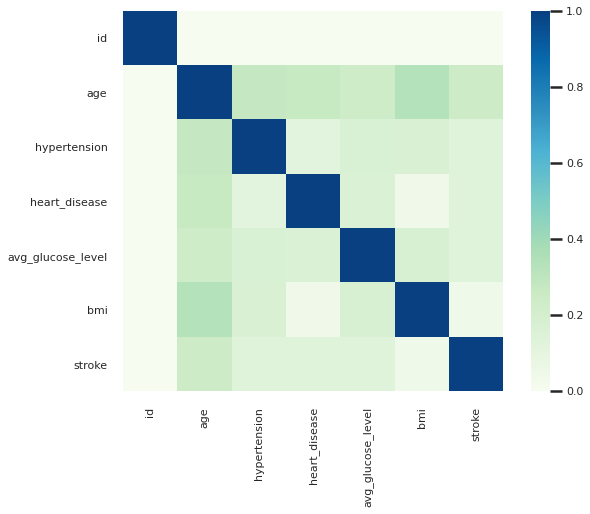

In [238]:
plt.subplots(figsize=(10,7))
sns.heatmap(corrmat, vmax=1,cmap="GnBu", square=True)

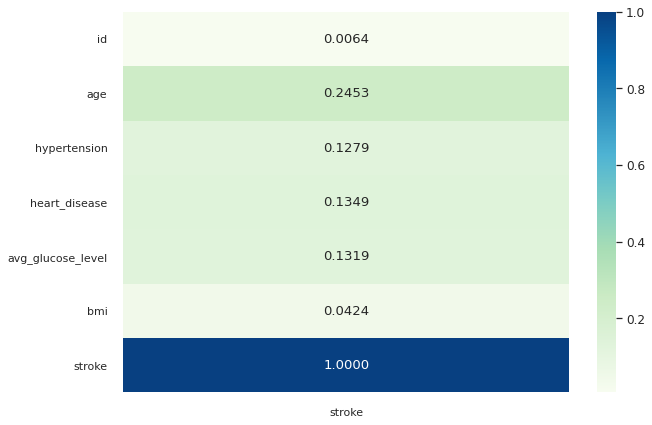

In [239]:
corr_stroke = data.corrwith(stroke, axis=0)
corr_stroke = pd.DataFrame(corr_stroke)
corr_stroke.rename (columns = {0: 'stroke'}, inplace = True)

#Oluşturulan korelasyon matrisinin görselleştirilmesi
plt.subplots(figsize=(10,7))
sns.set(font_scale=1.1)
sns.heatmap(corr_stroke, vmax=1, cmap="GnBu",fmt='.4f',annot=True);

**Gender & Stroke**

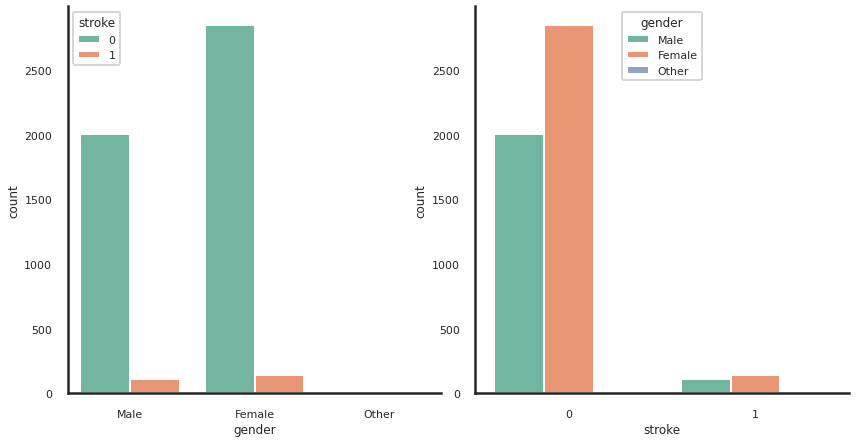

In [240]:
fig = plt.figure(figsize=(14,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)

gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='gender', hue='stroke', data=data, ax=gender_stroke, palette="Set2")
sns.despine()

gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=gender_stroke)
sns.countplot(x='stroke', hue='gender', data=data, ax=gender_stroke, palette="Set2")
sns.despine()

plt.show()

In [241]:
data.groupby('gender')["stroke"].count()

gender
Female    2994
Male      2115
Other        1
Name: stroke, dtype: int64

In [242]:
data.groupby(['gender', 'stroke'])['stroke'].count()

gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
Name: stroke, dtype: int64

**Worktype & Stroke**

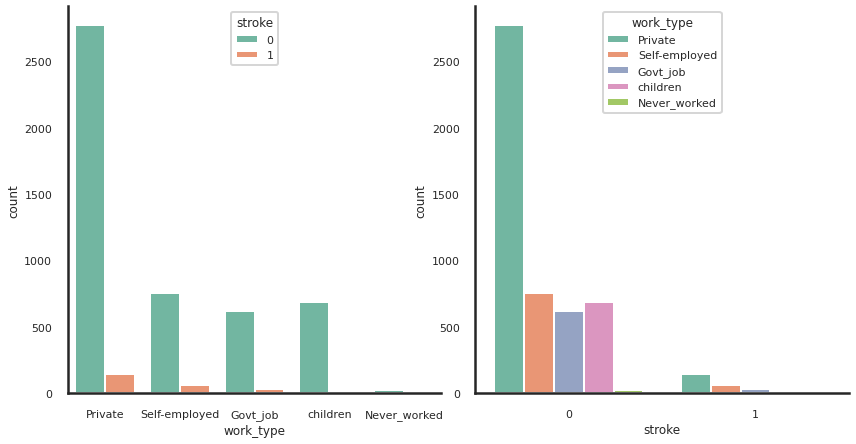

In [243]:
fig = plt.figure(figsize=(14,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)


ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='work_type', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='work_type', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()


plt.show()

When the graphs above are examined, it is not possible for children to have a stroke. The number of stroke  in private and self-employed groups is similar. However, the probability of people coming under government administration (govt_job) not having a stroke is higher than both classes. Perhaps this can be explained by the degree of pressure felt by the workers.

**Residence & Stroke**

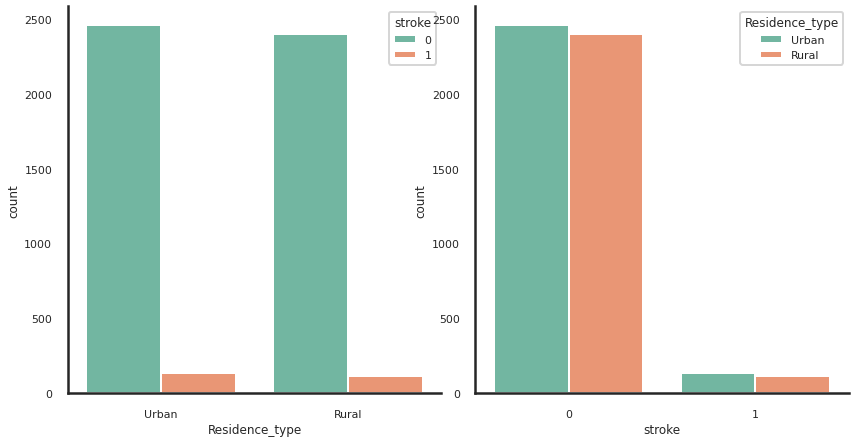

In [244]:
fig = plt.figure(figsize=(14,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)


ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='Residence_type', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='Residence_type', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()


plt.show()

In [245]:
data.groupby(['Residence_type', 'stroke'])['stroke'].count()

Residence_type  stroke
Rural           0         2400
                1          114
Urban           0         2461
                1          135
Name: stroke, dtype: int64

People living in rural areas  less prone to stroke than urban residents. It can be said that air pollution in cities may be related to having a stroke.

**Ever Married & Stroke**

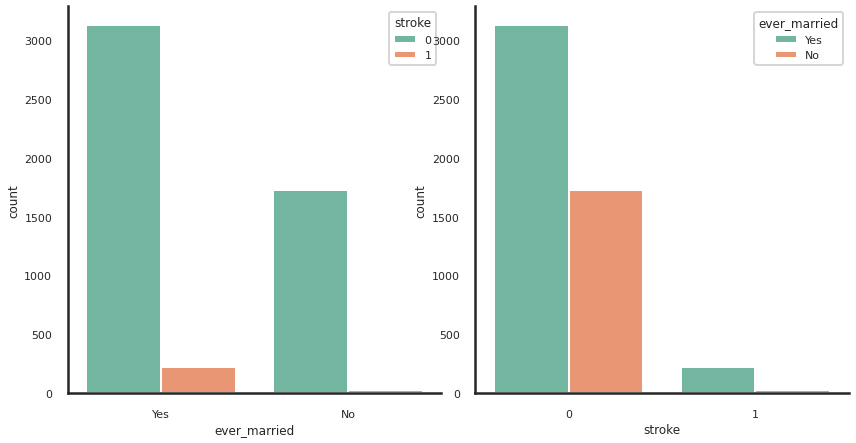

In [246]:
fig = plt.figure(figsize=(14,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)


ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='ever_married', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='ever_married', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

plt.show()

In [247]:
data.groupby(['ever_married', 'stroke'])['stroke'].count()

ever_married  stroke
No            0         1728
              1           29
Yes           0         3133
              1          220
Name: stroke, dtype: int64

There is a greater chance of stroke among people who have been married. It can be a meaningful feature.

**Smoking & Stroke**

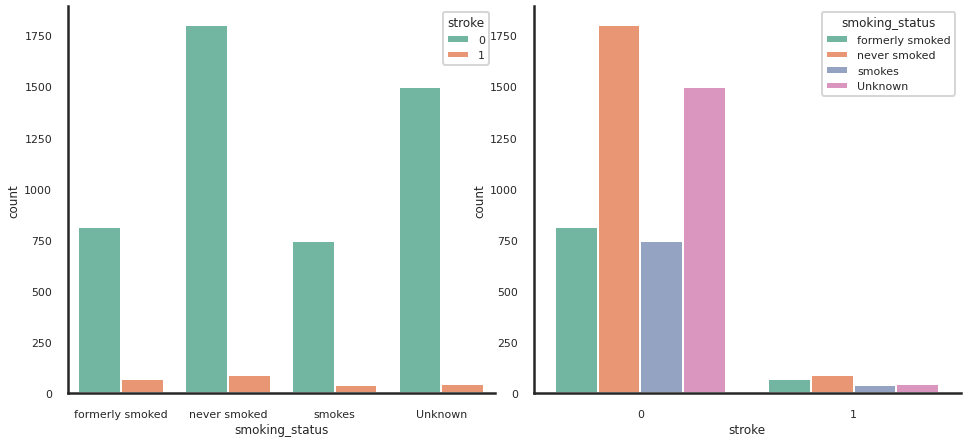

In [248]:
fig = plt.figure(figsize=(16,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)


ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='smoking_status', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='smoking_status', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

plt.show()

In [249]:
data['smoking_status'].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [250]:
data.groupby(['smoking_status', 'stroke'])['stroke'].count()

smoking_status   stroke
Unknown          0         1497
                 1           47
formerly smoked  0          815
                 1           70
never smoked     0         1802
                 1           90
smokes           0          747
                 1           42
Name: stroke, dtype: int64

It can be said that the correlation between stroke and smoking status is low, since the rate of stroke survivors is close between different smoking situations.

**Age & Stroke**

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


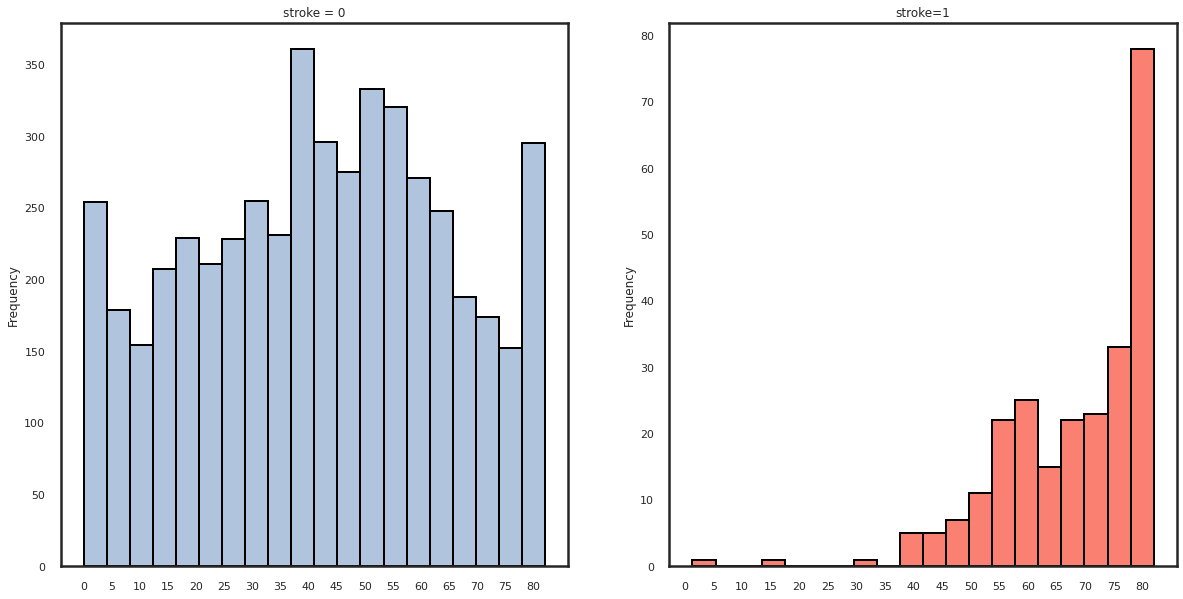

In [251]:
f,ax = plt.subplots(1,2, figsize=(20,10));

data.loc[data['stroke'] ==0]['age'].plot.hist(ax=ax[0], bins=20, edgecolor='black', color='lightsteelblue');
ax[0].set_title('stroke = 0');
ax1 = list(range(0, 85, 5));
ax[0].set_xticks(ax1);

data[data['stroke']==1]['age'].plot.hist(ax=ax[1], color='salmon', bins=20, edgecolor='black');
ax[1].set_title('stroke=1');
x2=list(range(0, 85, 5));
ax[1].set_xticks(x2);
plt.show();

It is seen that the risk of stroke increases with age

**Hypertension & Stroke**

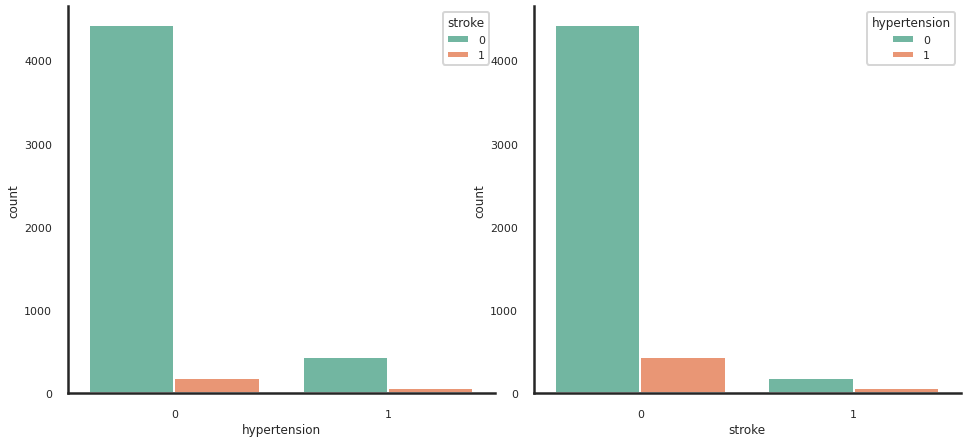

In [252]:
fig = plt.figure(figsize=(16,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)


ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='hypertension', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='hypertension', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()


plt.show()

In [253]:
data['hypertension'].value_counts()

0    4612
1     498
Name: hypertension, dtype: int64

In [254]:
data.groupby(['hypertension', 'stroke'])['stroke'].count()

hypertension  stroke
0             0         4429
              1          183
1             0          432
              1           66
Name: stroke, dtype: int64

**Heart Disease & Stroke**

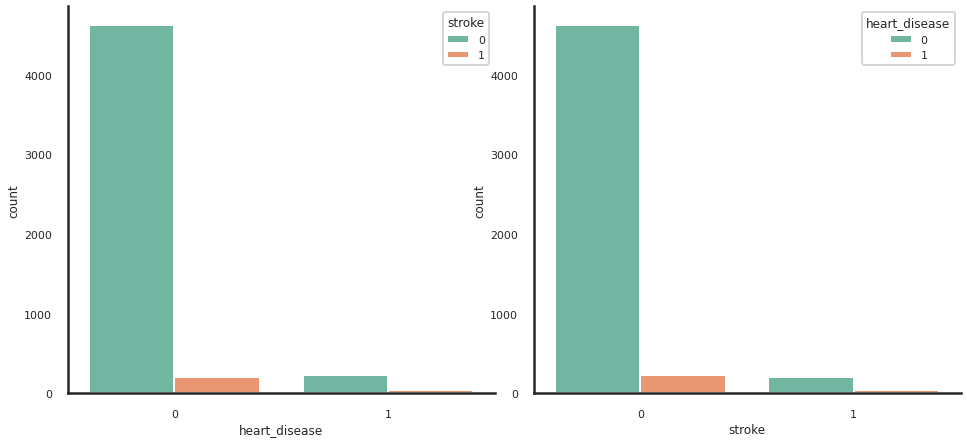

In [255]:
fig = plt.figure(figsize=(16,11))
gs = fig.add_gridspec(3,4)
sns.set_style("white")
sns.set_context("poster", font_scale = 0.5)

ax_gender_stroke = fig.add_subplot(gs[:2,:2])
sns.countplot(x='heart_disease', hue='stroke', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

ax_gender_stroke = fig.add_subplot(gs[:2,2:4], sharey=ax_gender_stroke)
sns.countplot(x='stroke', hue='heart_disease', data=data, ax=ax_gender_stroke, palette='Set2')
sns.despine()

plt.show()

In [256]:
data['heart_disease'].value_counts()

0    4834
1     276
Name: heart_disease, dtype: int64

In [257]:
data.groupby(['heart_disease', 'stroke'])['stroke'].count()

heart_disease  stroke
0              0         4632
               1          202
1              0          229
               1           47
Name: stroke, dtype: int64

Features of hypertension and heart disease have been found to be correlation with stroke.

**Glucose_level**

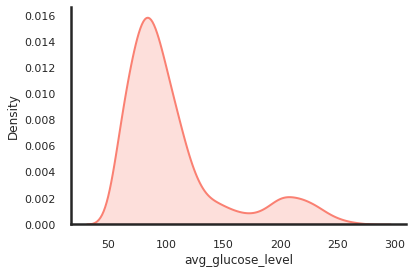

In [258]:
sns.kdeplot('avg_glucose_level', data=data, shade=True,color="salmon")
sns.set_style("white")
sns.despine()

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


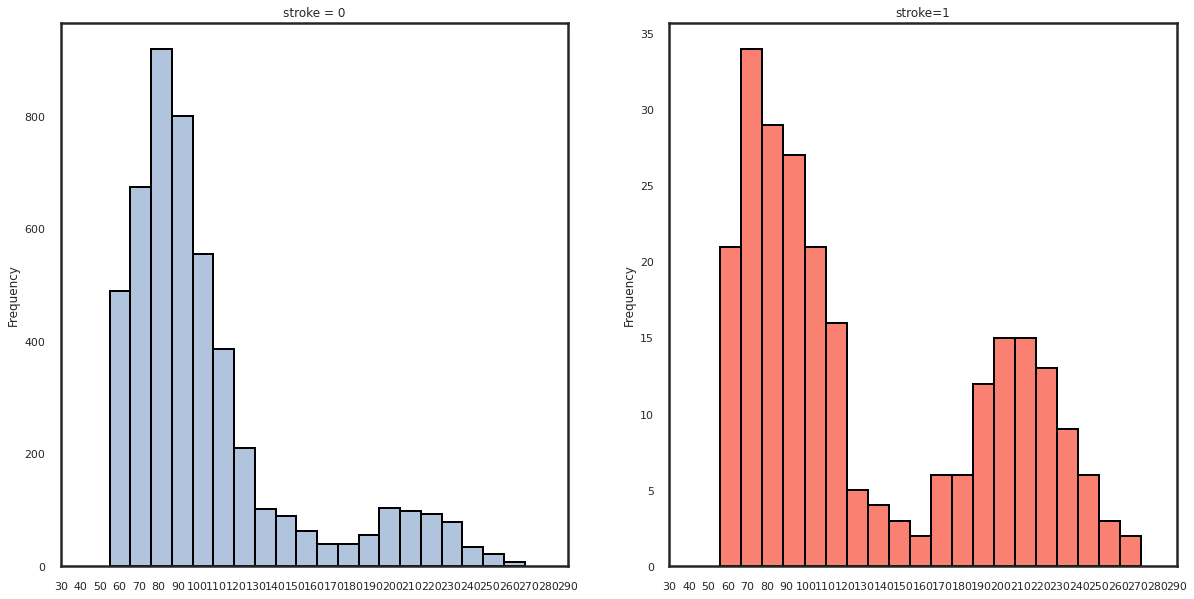

In [259]:
f,ax = plt.subplots(1,2, figsize=(20,10))

data.loc[data['stroke'] ==0]['avg_glucose_level'].plot.hist(ax=ax[0], bins=20, edgecolor='black', color='lightsteelblue')
ax[0].set_title('stroke = 0')
ax1 = list(range(30, 300, 10))
ax[0].set_xticks(ax1)

data.loc[data['stroke']==1]['avg_glucose_level'].plot.hist(ax=ax[1], color='salmon', bins=20, edgecolor='black')
ax[1].set_title('stroke=1')
x2= list(range(30, 300, 10))
ax[1].set_xticks(x2)
plt.show()

**BMI**

/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():
/opt/conda/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


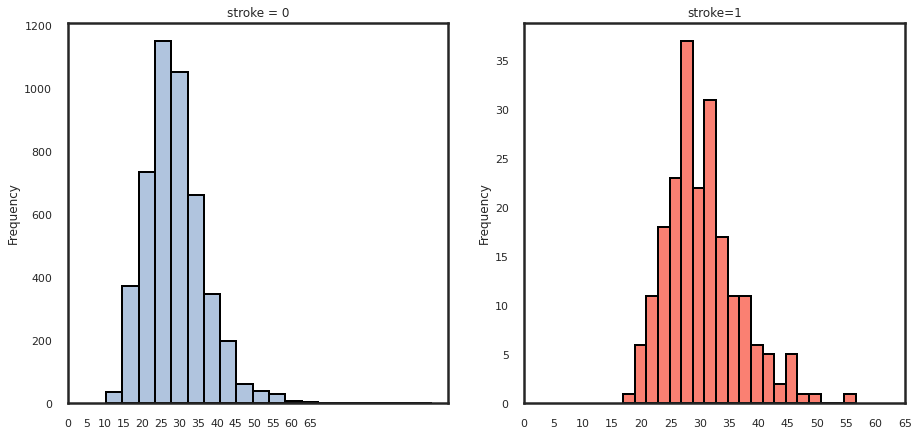

In [260]:
f,ax = plt.subplots(1,2, figsize=(15,7))

data.loc[data['stroke'] ==0]['bmi'].plot.hist(ax=ax[0], bins=20, edgecolor='black', color='lightsteelblue')
ax[0].set_title('stroke = 0')
ax1 = list(range(0, 70, 5))
ax[0].set_xticks(ax1)

data.loc[data['stroke']==1]['bmi'].plot.hist(ax=ax[1], color='salmon', bins=20, edgecolor='black')
ax[1].set_title('stroke=1')
x2= list(range(0, 70, 5))
ax[1].set_xticks(x2)
plt.show()

# DATA CLEANING AND EXAMINATION OF MISSING DATA

In [261]:
data = data.drop("id", axis="columns")
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [262]:
data_delete = data[data['gender'] == 'Other'].index
data.drop(data_delete)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


The "other" attribute in the gender column was deleted as an outlier.

In [263]:
smoking_status = data['smoking_status']
smoking_status

0       formerly smoked
1          never smoked
2          never smoked
3                smokes
4          never smoked
             ...       
5105       never smoked
5106       never smoked
5107       never smoked
5108    formerly smoked
5109            Unknown
Name: smoking_status, Length: 5110, dtype: object

In [264]:
for index in range(smoking_status.size):
    if smoking_status.iloc[index] == "Unknown":
        smoking_status.iloc[index] = np.nan

smoking_status

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


0       formerly smoked
1          never smoked
2          never smoked
3                smokes
4          never smoked
             ...       
5105       never smoked
5106       never smoked
5107       never smoked
5108    formerly smoked
5109                NaN
Name: smoking_status, Length: 5110, dtype: object

In [265]:
total = data.isnull().sum().sort_values(ascending=False)

missing_data = pd.concat([total], axis=1, keys=['Toplam'])
missing_data = missing_data
missing_data.head(12)

,Toplam
smoking_status,1544
bmi,201
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0


In [266]:
ever_married = data["ever_married"]
ever_married

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
5105    Yes
5106    Yes
5107    Yes
5108    Yes
5109    Yes
Name: ever_married, Length: 5110, dtype: object

In [267]:
for index in range(ever_married.size):
    if ever_married.iloc[index] == "Yes":
        ever_married.iloc[index] = 1
    else:
        ever_married.iloc[index] = 0

data["ever_married"] = ever_married

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [268]:
data["ever_married"].value_counts()

1    3353
0    1757
Name: ever_married, dtype: int64

In [269]:
total = data.isnull().sum().sort_values(ascending=False)

missing_data = pd.concat([total], axis=1, keys=['Toplam'])
missing_data = missing_data
missing_data.head(12)

,Toplam
smoking_status,1544
bmi,201
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0


Body mass index (BMI) can be defined as the measurement of a person's weight in proportion to his or her weight. In other words, it is obtained by dividing the person's weight in kilograms by the square of their height in meters.

BMI = body weight (kg) / (height(m) x height(m))

We will use KNN to complete the missing data in the BMI column, the first we will create dummy data

In [270]:
data_copy = data.copy()

numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
categorial_cols = []

for col in data_copy.columns:
    if data_copy[col].dtype not in numeric_dtypes:
        categorial_cols.append(col)
    else:
        continue

data_dummy = pd.get_dummies(data_copy[categorial_cols])
data_copy = data.drop(categorial_cols, axis='columns')
data_dummy  = pd.concat([data_copy,data_dummy], axis=1)

data_dummy.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_0,...,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,0,1,0,0,0,1,1,0,0
1,61.0,0,0,202.21,NaN,1,1,0,0,0,...,0,0,0,1,0,1,0,0,1,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,0,1,0,0,0,1,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,0,1,0,1,0,0,1,0


In [271]:
var_names = list(data_dummy)
array_data = np.array(data_dummy)
data_dummy = knnimput.KNN(k = 4).complete(array_data)
data_dummy = pd.DataFrame(data_dummy, columns = var_names)

Imputing row 1/5110 with 0 missing, elapsed time: 5.842
Imputing row 101/5110 with 0 missing, elapsed time: 5.844
Imputing row 201/5110 with 1 missing, elapsed time: 5.846
Imputing row 301/5110 with 0 missing, elapsed time: 5.847
Imputing row 401/5110 with 0 missing, elapsed time: 5.848
Imputing row 501/5110 with 0 missing, elapsed time: 5.848
Imputing row 601/5110 with 0 missing, elapsed time: 5.849
Imputing row 701/5110 with 0 missing, elapsed time: 5.850
Imputing row 801/5110 with 0 missing, elapsed time: 5.851
Imputing row 901/5110 with 0 missing, elapsed time: 5.852
Imputing row 1001/5110 with 0 missing, elapsed time: 5.853
Imputing row 1101/5110 with 0 missing, elapsed time: 5.854
Imputing row 1201/5110 with 0 missing, elapsed time: 5.855
Imputing row 1301/5110 with 1 missing, elapsed time: 5.856
Imputing row 1401/5110 with 0 missing, elapsed time: 5.857
Imputing row 1501/5110 with 0 missing, elapsed time: 5.858
Imputing row 1601/5110 with 0 missing, elapsed time: 5.858
Imputing 

In [272]:
data_dummy.head(10)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_0,...,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0.0,1.0,228.69,36.600000,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,61.0,0.0,0.0,202.21,27.017583,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,80.0,0.0,1.0,105.92,32.500000,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,49.0,0.0,0.0,171.23,34.400000,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,79.0,1.0,0.0,174.12,24.000000,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
5,81.0,0.0,0.0,186.21,29.000000,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6,74.0,1.0,1.0,70.09,27.400000,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,69.0,0.0,0.0,94.39,22.800000,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,59.0,0.0,0.0,76.15,22.786498,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,78.0,0.0,0.0,58.57,24.200000,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [273]:
total = data_knn_dummy.isnull().sum().sort_values(ascending=False)

missing_data = pd.concat([total], axis=1, keys=['Toplam'])
missing_data = missing_data
missing_data.head(12)

,Toplam
age,0
work_type_Govt_job,0
smoking_status_never smoked,0
smoking_status_formerly smoked,0
Residence_type_Urban,0
Residence_type_Rural,0
work_type_children,0
work_type_Self-employed,0
work_type_Private,0
work_type_Never_worked,0


# MODEL

In [274]:
X = data_dummy
y = stroke
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_0,...,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
3897,4.00,0.0,0.0,90.42,16.2,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
576,29.00,0.0,0.0,207.58,22.8,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4013,44.00,1.0,0.0,91.28,26.5,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4536,68.00,1.0,0.0,150.74,40.3,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1180,62.00,0.0,0.0,82.57,36.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,43.00,0.0,0.0,88.00,30.6,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
466,61.00,1.0,0.0,170.05,60.2,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3092,1.16,0.0,0.0,97.28,17.8,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3772,80.00,0.0,0.0,196.08,31.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


**RANDOM FOREST**

In [275]:
rf_model = RandomForestClassifier()

rf_params = {"max_depth": [2,5],
             "max_features": [2,3],
             "n_estimators": [2,5,10,15],
             "min_samples_split": [2,3]}

rf_cv_model = GridSearchCV(rf_model, rf_params, cv=10, n_jobs=-1, verbose=2).fit(X_train,y_train)

Fitting 10 folds for each of 32 candidates, totalling 320 fits


In [276]:
print("Best Parameters: " + str(rf_cv_model.best_params_))

Best Parameters: {'max_depth': 5, 'max_features': 3, 'min_samples_split': 3, 'n_estimators': 15}


In [277]:
data_grid_rf = pd.DataFrame(rf_cv_model.cv_results_)
data_grid_rf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015643,0.003627,0.005385,0.000434,2,2,2,2,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.969274,...,0.974860,0.955307,0.955307,1.000000,0.955182,0.955182,0.955182,0.963091,0.014032,20
1,0.025580,0.002099,0.005740,0.000611,2,2,2,5,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.974790,0.957230,0.005853,26
2,0.054297,0.013028,0.008083,0.002379,2,2,2,10,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,30
3,0.063952,0.004401,0.007849,0.000300,2,2,2,15,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.957784,0.007555,25
4,0.013607,0.000785,0.004741,0.000443,2,2,3,2,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.994413,...,0.955307,0.955307,1.000000,1.000000,0.955182,0.960784,0.955182,0.971752,0.019478,18
5,0.025500,0.001436,0.006011,0.000313,2,2,3,5,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,30
6,0.047611,0.007709,0.007103,0.000987,2,2,3,10,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.958063,0.008393,24
7,0.070072,0.008675,0.008425,0.001295,2,2,3,15,"{'max_depth': 2, 'max_features': 2, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,30
8,0.014894,0.003467,0.004909,0.000316,2,3,2,2,"{'max_depth': 2, 'max_features': 3, 'min_sampl...",0.972067,...,1.000000,0.980447,0.997207,0.966480,0.971989,0.969188,1.000000,0.985738,0.014120,6
9,0.025405,0.000640,0.005763,0.000344,2,3,2,5,"{'max_depth': 2, 'max_features': 3, 'min_sampl...",0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.957983,0.955182,0.955550,0.000813,29


In [278]:
rf_best_model=rf_cv_model.best_estimator_

#Best model score

rf_crossVal = rf_cv_model.best_score_
rf_crossVal

0.9918806628796769

In [279]:
rf_best_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, max_features=3, min_samples_split=3,
                       n_estimators=15)

In [280]:
rf_best_model.score(X_test, y_test)

0.9973907371167645

In [281]:
y_pred_rf = rf_best_model.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0])

**SUPPORT VECTOR MACHINE**

In [282]:
svc_model = SVC()

svc_params = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-6],'C': [2, 10,25]}]

svc_cv_model = GridSearchCV(svc_model, svc_params, cv=10, n_jobs=-1, verbose=2).fit(X_train,y_train)


Fitting 10 folds for each of 6 candidates, totalling 60 fits


In [283]:
print("Best parameters: " + str(svc_cv_model.best_params_))

Best parameters: {'C': 25, 'gamma': 0.001, 'kernel': 'rbf'}


In [284]:
data_grid_svc = pd.DataFrame(svc_cv_model.cv_results_)
data_grid_svc

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.428391,0.011591,0.031751,0.001671,2,0.001,rbf,"{'C': 2, 'gamma': 0.001, 'kernel': 'rbf'}",0.955307,0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,3
1,0.142176,0.003748,0.022989,0.000921,2,0.000001,rbf,"{'C': 2, 'gamma': 1e-06, 'kernel': 'rbf'}",0.955307,0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,3
2,0.578930,0.028625,0.029417,0.001417,10,0.001,rbf,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",0.963687,0.958101,...,0.958101,0.960894,0.958101,0.960894,0.960784,0.957983,0.963585,0.960302,0.002084,2
3,0.219832,0.021043,0.032781,0.004794,10,0.000001,rbf,"{'C': 10, 'gamma': 1e-06, 'kernel': 'rbf'}",0.955307,0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,3
4,0.728352,0.084070,0.027768,0.001951,25,0.001,rbf,"{'C': 25, 'gamma': 0.001, 'kernel': 'rbf'}",0.988827,0.991620,...,0.983240,0.994413,0.991620,0.994413,0.994398,0.994398,0.997199,0.992175,0.003703,1
5,0.289057,0.036227,0.035704,0.007073,25,0.000001,rbf,"{'C': 25, 'gamma': 1e-06, 'kernel': 'rbf'}",0.955307,0.955307,...,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.955270,0.000057,3


In [285]:
svc_best_model = svc_cv_model.best_estimator_

svc_crossVal = svc_cv_model.best_score_
svc_crossVal

0.9921748587703239

In [286]:
svc_best_model.fit(X_train, y_train)

SVC(C=25, gamma=0.001)

In [287]:
svc_best_model.score(X_test, y_test)

0.9941291585127201

In [288]:
y_pred_svc = svc_best_model.predict(X_test)
y_pred_svc

array([0, 0, 0, ..., 0, 0, 0])

**LOGISTIC REGRESSION**

In [289]:
lg_model = LogisticRegression()

lg_params = {"C":np.logspace(-3,-4,4,3,7), "penalty":["l1","l2"]}


lg_cv_model = GridSearchCV(lg_model, lg_params, cv=10, n_jobs=-1, verbose=2).fit(X_train,y_train)

Fitting 10 folds for each of 8 candidates, totalling 80 fits


/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_search.py:921: UserWarning: One or more of the test scores are non-finite: [       nan 0.95526971        nan 0.95526971        nan 0.95526971
        nan 0.95526971]
  category=UserWarning


In [290]:
print("Best Parameters: " + str(lg_cv_model.best_params_))

Best Parameters: {'C': 0.0029154518950437317, 'penalty': 'l2'}


In [291]:
data_grid_lg = pd.DataFrame(lg_cv_model.cv_results_)
data_grid_lg

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001418,0.000290,0.000000,0.000000,0.002915,l1,"{'C': 0.0029154518950437317, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
1,0.106312,0.009772,0.004248,0.000180,0.002915,l2,"{'C': 0.0029154518950437317, 'penalty': 'l2'}",0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.95527,0.000057,1
2,0.001505,0.000320,0.000000,0.000000,0.001524,l1,"{'C': 0.001524075680975831, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,0.090795,0.011608,0.004305,0.000245,0.001524,l2,"{'C': 0.001524075680975831, 'penalty': 'l2'}",0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.95527,0.000057,1
4,0.001710,0.000238,0.000000,0.000000,0.000797,l1,"{'C': 0.0007967226917002873, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
5,0.082124,0.008638,0.004392,0.000141,0.000797,l2,"{'C': 0.0007967226917002873, 'penalty': 'l2'}",0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.95527,0.000057,1
6,0.001706,0.000108,0.000000,0.000000,0.000416,l1,"{'C': 0.00041649312786339027, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
7,0.069799,0.009924,0.004009,0.000740,0.000416,l2,"{'C': 0.00041649312786339027, 'penalty': 'l2'}",0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955307,0.955182,0.955182,0.955182,0.95527,0.000057,1


In [292]:
lg_best_model = lg_cv_model.best_estimator_

lg_crossVal = lg_cv_model.best_score_
lg_crossVal

0.9552697056476223

In [293]:
lg_best_model.fit(X_train, y_train)

LogisticRegression(C=0.0029154518950437317)

In [294]:
lg_best_model.score(X_test, y_test)

0.9419439008480104

In [295]:
y_pred_lg = lg_best_model.predict(X_test)
y_pred_lg

array([0, 0, 0, ..., 0, 0, 0])

**BEST MODEL SELECT**

----------------------------------------
RandomForestClassifier:
Test Accuracy: 99.7391%


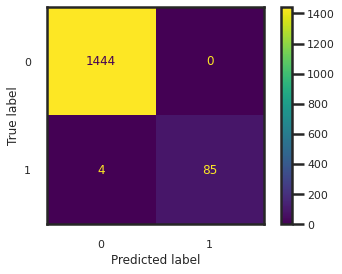

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1444
           1       1.00      0.96      0.98        89

    accuracy                           1.00      1533
   macro avg       1.00      0.98      0.99      1533
weighted avg       1.00      1.00      1.00      1533

----------------------------------------
SVC:
Test Accuracy: 99.4129%


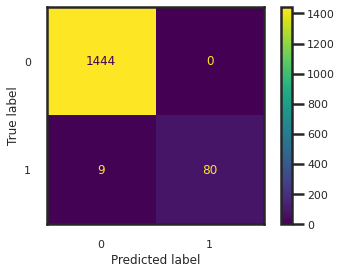

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1444
           1       1.00      0.90      0.95        89

    accuracy                           0.99      1533
   macro avg       1.00      0.95      0.97      1533
weighted avg       0.99      0.99      0.99      1533

----------------------------------------
LogisticRegression:
Test Accuracy: 94.1944%


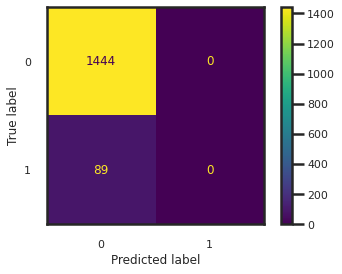

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1444
           1       0.00      0.00      0.00        89

    accuracy                           0.94      1533
   macro avg       0.47      0.50      0.49      1533
weighted avg       0.89      0.94      0.91      1533



/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [296]:
models = [rf_best_model,svc_best_model,lg_best_model]

for model in models:
    name = model.__class__.__name__
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("-"*40)
    print(name + ":" )
    print("Test Accuracy: {:.4%}".format(accuracy))
    plot_confusion_matrix(model,X_test,y_test)
    plt.show()
    print(classification_report(y_test,y_pred))

In [297]:
seeds=np.arange(10**4)
np.random.shuffle(seeds)
seeds

array([6874, 1557, 9029, ..., 3711, 6855, 8718])

In [298]:
seeds=seeds[:35]
seeds

array([6874, 1557, 9029, 7016, 9775, 8262, 8554, 3930, 5294, 3099, 6512,
        254, 4888, 2111,  871, 2117, 8759, 1422, 8545, 7219, 2183, 5382,
       7236, 1139, 9476, 5390,  571, 3643,  829, 1905, 8821, 8697, 6430,
       1452, 9333])

In [299]:
accuracy_rf = []
accuracy_svc = []
accuracy_lg = []

for i in seeds:
    X_train,X_test,y_train,y_tets=train_test_split(X,y,
                                                  test_size=0.30,
                                                  random_state=i,
                                                  stratify=y)
    rf_best_model.fit(X_train,y_train)
    rf_i_acc = rf_best_model.score(X_test,y_test)
    accuracy_rf.append(rf_i_acc)
    
    
    svc_best_model.fit(X_train,y_train)
    svc_i_acc = svc_best_model.score(X_test,y_test)
    accuracy_svc.append(svc_i_acc)
    
    lg_model.fit(X_train,y_train)
    lg_acc = lg_model.score(X_test,y_test)
    accuracy_lg.append(lg_acc)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [300]:
accuracy_rf

[0.9243313763861709,
 0.9047619047619048,
 0.9015003261578604,
 0.9015003261578604,
 0.9015003261578604,
 0.9334637964774951,
 0.9204174820613177,
 0.903457273320287,
 0.9080234833659491,
 0.9001956947162426,
 0.9256360078277887,
 0.9008480104370515,
 0.8995433789954338,
 0.9197651663405088,
 0.9021526418786693,
 0.9151989562948467,
 0.9125896934116112,
 0.9021526418786693,
 0.9125896934116112,
 0.908675799086758,
 0.898238747553816,
 0.9119373776908023,
 0.9099804305283757,
 0.9145466405740378,
 0.8975864318330071,
 0.9282452707110241,
 0.9262883235485975,
 0.913894324853229,
 0.9080234833659491,
 0.9171559034572733,
 0.9073711676451403,
 0.9080234833659491,
 0.9021526418786693,
 0.9028049575994781,
 0.91324200913242]

In [301]:
accuracy_svc

[0.9067188519243313,
 0.8975864318330071,
 0.9015003261578604,
 0.9028049575994781,
 0.9041095890410958,
 0.8962818003913894,
 0.9060665362035225,
 0.9047619047619048,
 0.9041095890410958,
 0.9073711676451403,
 0.8995433789954338,
 0.9001956947162426,
 0.903457273320287,
 0.9073711676451403,
 0.9080234833659491,
 0.9054142204827136,
 0.9008480104370515,
 0.9047619047619048,
 0.903457273320287,
 0.903457273320287,
 0.898238747553816,
 0.9054142204827136,
 0.9015003261578604,
 0.9015003261578604,
 0.8995433789954338,
 0.9073711676451403,
 0.9028049575994781,
 0.9073711676451403,
 0.9028049575994781,
 0.9041095890410958,
 0.9008480104370515,
 0.9041095890410958,
 0.9021526418786693,
 0.903457273320287,
 0.9060665362035225]

In [302]:
accuracy_lg

[0.8995433789954338,
 0.8956294846705806,
 0.8969341161121983,
 0.8995433789954338,
 0.9008480104370515,
 0.8956294846705806,
 0.8995433789954338,
 0.898238747553816,
 0.898238747553816,
 0.8995433789954338,
 0.8956294846705806,
 0.8995433789954338,
 0.898238747553816,
 0.9021526418786693,
 0.9021526418786693,
 0.9008480104370515,
 0.8956294846705806,
 0.8995433789954338,
 0.8995433789954338,
 0.898238747553816,
 0.8956294846705806,
 0.9021526418786693,
 0.9008480104370515,
 0.8969341161121983,
 0.8969341161121983,
 0.9008480104370515,
 0.8956294846705806,
 0.9008480104370515,
 0.898238747553816,
 0.8995433789954338,
 0.898238747553816,
 0.9021526418786693,
 0.9008480104370515,
 0.8995433789954338,
 0.9008480104370515]

In [303]:
d = {'rf_accuracy': accuracy_rf, 'svc_accuracy': accuracy_svc,'lg_accuracy': accuracy_lg}
accuracies = pd.DataFrame(data=d)
accuracies

,rf_accuracy,svc_accuracy,lg_accuracy
0,0.924331,0.906719,0.899543
1,0.904762,0.897586,0.895629
2,0.901500,0.901500,0.896934
3,0.901500,0.902805,0.899543
4,0.901500,0.904110,0.900848
5,0.933464,0.896282,0.895629
6,0.920417,0.906067,0.899543
7,0.903457,0.904762,0.898239
8,0.908023,0.904110,0.898239
9,0.900196,0.907371,0.899543


In [304]:
accuracies.describe().T

,count,mean,std,min,25%,50%,75%,max
rf_accuracy,35.0,0.910223,0.009499,0.897586,0.902153,0.908023,0.914873,0.933464
svc_accuracy,35.0,0.903290,0.002974,0.896282,0.901500,0.903457,0.905414,0.908023
lg_accuracy,35.0,0.898984,0.002106,0.895629,0.897586,0.899543,0.900848,0.902153


<AxesSubplot:>

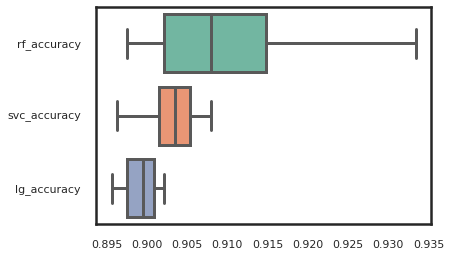

In [305]:
sns.boxplot(data = accuracies, orient="h", palette="Set2")

In [306]:
stat, p = friedmanchisquare(accuracy_rf, accuracy_svc ,accuracy_lg)
print('Statistics = %.3f, p=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Same proportions of errors (fail to reject H0)')
else:
    print('Different proportions of errors (reject H0)')

Statistics = 55.191, p=0.000
Different proportions of errors (reject H0)


There is a significant difference between the algorithms. Random forest was chosen as the best model because it is the random forest algorithm with the highest average of the prediction values

**FINAL MODEL**

In [307]:
final_model = RandomForestClassifier(max_depth = 5, max_features = 3, n_estimators = 2)
final_tuned = final_model.fit(X_train,y_train)

y_pred_test = final_tuned.predict(X_test)
y_pred_test

array([0, 0, 0, ..., 0, 0, 0])

In [308]:
print('Training Accuracy: ',accuracy_score(y_train,final_model.predict(X_train)))
print('Test Accuracy: ',accuracy_score(y_test,final_model.predict(X_test)))

Training Accuracy:  0.976237070170534
Test Accuracy:  0.9249836921069797


**FEATURE SELECTION BY IMPORTANCE**

In [309]:
rf_Importance = pd.DataFrame({"Importance":final_tuned.feature_importances_*100},index = X_train.columns)

s = rf_Importance.sort_values(by = "Importance", axis=0, ascending = False)
s


,Importance
stroke,65.416456
age,14.463295
avg_glucose_level,8.597166
bmi,2.590593
smoking_status_never smoked,2.238603
hypertension,2.118478
heart_disease,1.665684
ever_married_0,1.147681
smoking_status_formerly smoked,0.814073
work_type_Self-employed,0.764498


In [310]:
new_train_columns = []

for index, row in rf_Importance.iterrows():
    if(row["Importance"] >= 0.06):
        new_train_columns.append(index)
    
new_train = X_train[new_train_columns]

X_train = new_train
X_test = X_test[new_train_columns]
rf_model = RandomForestClassifier(max_depth = 5, max_features = 3, n_estimators = 2)
rf_tuned = rf_model.fit(X_train,y_train)

y_pred = rf_tuned.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [311]:
print('Training Accuracy: ',accuracy_score(y_train,rf_model.predict(X_train)))
print('Test Accuracy: ',accuracy_score(y_test,rf_model.predict(X_test)))

Training Accuracy:  0.9823874755381604
Test Accuracy:  0.91324200913242
